
[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Correlation Matrix:
Ticker       Cocoa  Crude Oil  Cotton  Gold  Copper  Coffee  Natural Gas  \
Ticker                                                                     
Cocoa         1.00       0.03    0.04  0.06    0.05    0.15        -0.01   
Crude Oil     0.03       1.00    0.05  0.03    0.10    0.06         0.01   
Cotton        0.04       0.05    1.00  0.08    0.21    0.11         0.05   
Gold          0.06       0.03    0.08  1.00    0.30    0.11         0.02   
Copper        0.05       0.10    0.21  0.30    1.00    0.16         0.01   
Coffee        0.15       0.06    0.11  0.11    0.16    1.00         0.04   
Natural Gas  -0.01       0.01    0.05  0.02    0.01    0.04         1.00   
Sugar         0.08       0.12    0.14  0.07    0.11    0.19         0.01   
Silver        0.07       0.04    0.13  0.78    0.42    0.13         0.02   
Corn         -0.01       0.10  

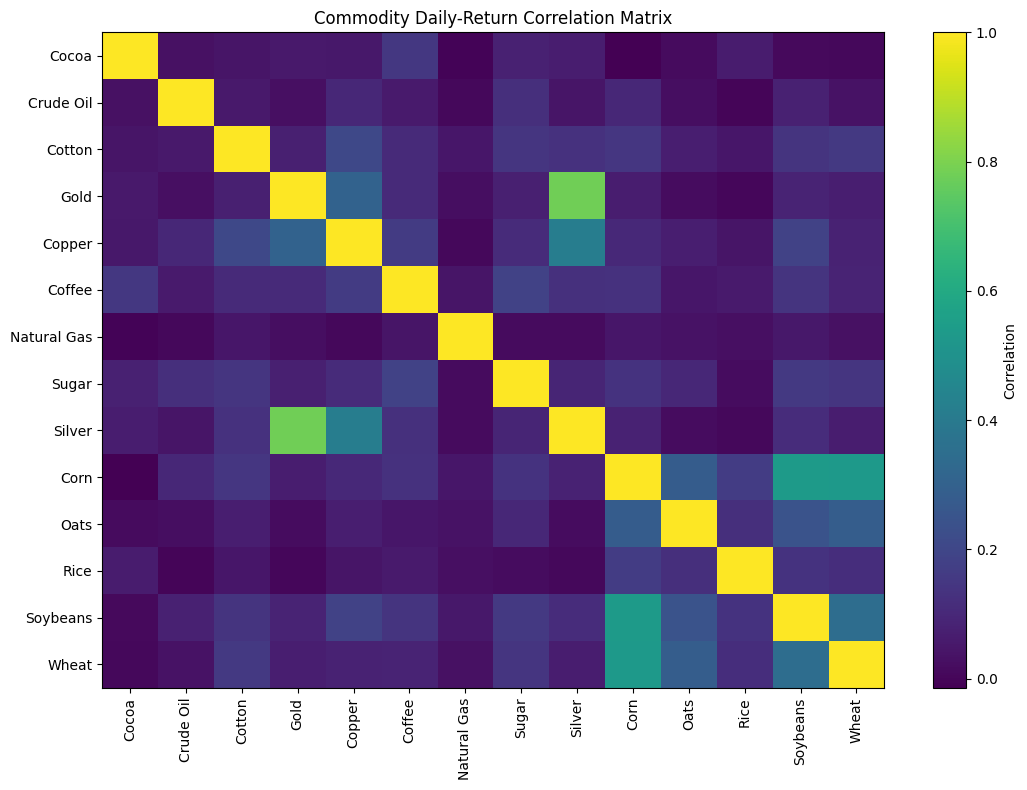

In [3]:
!pip install yfinance pandas matplotlib statsmodels

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Commodities to compare
tickers = {
    "Corn": "ZC=F",
    "Wheat": "ZW=F",
    "Soybeans": "ZS=F",
    "Oats": "ZO=F",
    "Rice": "ZR=F",
    "Coffee": "KC=F",
    "Cocoa": "CC=F",
    "Sugar": "SB=F",
    "Cotton": "CT=F",
    "Crude Oil": "CL=F",
    "Natural Gas": "NG=F",
    "Gold": "GC=F",
    "Silver": "SI=F",
    "Copper": "HG=F"
}

# Download 10 years of daily data
data = yf.download(
    list(tickers.values()),
    period="10y",
    interval="1d",
    auto_adjust=False,
    progress=False
)

# Extract closing prices and rename columns
prices = data["Close"]
prices = prices.rename(columns={symbol: name for name, symbol in tickers.items()})
prices = prices.dropna(axis=1, how="all")

# Calculate daily returns
returns = prices.pct_change(fill_method=None)

# Correlation matrix
correlation_matrix = returns.corr()

print("Correlation Matrix:")
print(correlation_matrix.round(2))

# Find the most highly correlated pairs
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

top_pairs = upper_triangle.stack().sort_values(ascending=False)

print("\nTop 10 Most Correlated Pairs:")
print(top_pairs.head(10))

# Save files
prices.to_csv("commodity_prices.csv")
returns.to_csv("commodity_returns.csv")
correlation_matrix.to_csv("commodity_correlation_matrix.csv")

# Display correlation heatmap
plt.figure(figsize=(11, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.index)),
           correlation_matrix.index)
plt.title("Commodity Daily-Return Correlation Matrix")
plt.tight_layout()
plt.show()

### Cointegration Test

Correlation only says prices move together day-to-day. Cointegration asks whether the *spread* is mean-reverting — which is what pairs trading needs. We screen every commodity pair with the Engle-Granger test on log prices; look for low p-values (ideally < 0.05).

In [4]:
# Cointegration is the right test for pairs trading:
# high correlation ≠ mean-reverting spread. We need a stationary residual.
from itertools import combinations
from statsmodels.tsa.stattools import coint

# Use log prices (standard for Engle-Granger cointegration)
log_prices = np.log(prices)

results = []
for a, b in combinations(log_prices.columns, 2):
    pair = log_prices[[a, b]].dropna()
    if len(pair) < 252:  # need enough history
        continue
    t_stat, p_value, crit = coint(pair[a], pair[b])
    corr = returns[[a, b]].corr().iloc[0, 1]
    results.append({
        "Pair": f"{a} / {b}",
        "P-value": p_value,
        "T-stat": t_stat,
        "Corr": corr,
        "N": len(pair),
    })

coint_results = (
    pd.DataFrame(results)
    .sort_values("P-value")
    .reset_index(drop=True)
)

print("All pairs ranked by cointegration p-value (lower = stronger evidence):")
print(coint_results.round(4).to_string(index=False))

print("\nCandidates with p < 0.05:")
sig = coint_results[coint_results["P-value"] < 0.05]
print(sig.round(4).to_string(index=False) if len(sig) else "None found at 5% significance.")

# Keep the best pair for the next step (spread / z-score trading)
best = coint_results.iloc[0]
print(f"\nBest candidate: {best['Pair']} (p={best['P-value']:.4f}, corr={best['Corr']:.3f})")
best_a, best_b = [s.strip() for s in best["Pair"].split("/")]
selected_pair = log_prices[[best_a, best_b]].dropna()


/Users/adamqattan/Downloads/MMF Operations Research/.venv/lib/python3.11/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


All pairs ranked by cointegration p-value (lower = stronger evidence):
                   Pair  P-value  T-stat    Corr    N
           Oats / Wheat   0.0017 -4.4134  0.2845 2512
           Corn / Wheat   0.0035 -4.2135  0.5287 2510
      Crude Oil / Wheat   0.0107 -3.8766  0.0356 2511
Crude Oil / Natural Gas   0.0109 -3.8695  0.0075 2512
        Corn / Soybeans   0.0129 -3.8159  0.5400 2510
   Crude Oil / Soybeans   0.0205 -3.6616  0.0793 2511
       Crude Oil / Corn   0.0223 -3.6329  0.0997 2509
     Natural Gas / Corn   0.0263 -3.5744  0.0460 2510
     Crude Oil / Coffee   0.0265 -3.5719  0.0591 2512
          Cotton / Corn   0.0283 -3.5490  0.1448 2510
   Cotton / Natural Gas   0.0298 -3.5303  0.0475 2514
         Cotton / Wheat   0.0301 -3.5272  0.1559 2512
      Cotton / Soybeans   0.0304 -3.5230  0.1384 2512
       Soybeans / Wheat   0.0304 -3.5229  0.3472 2512
          Cotton / Oats   0.0312 -3.5132  0.0702 2512
     Natural Gas / Oats   0.0448 -3.3781  0.0336 2512
        Cop

### Data Quality — Corn & Wheat

Chosen pair: **Corn (`ZC=F`) / Wheat (`ZW=F`)**. Before building a spread or backtest, we inspect whether the Yahoo continuous-futures Close series is clean enough to trust: history length, missing values, gaps, bad prints, outliers, and continuous-contract caveats.

1. HISTORY / COVERAGE
Series:            ['Corn', 'Wheat']
Start date:        2016-07-29
End date:          2026-07-29
Calendar span:     3652 days
Rows in pull:      2,514
Trading days/year: 251.4

Head:
Ticker        Corn   Wheat
Date                      
2016-07-29  334.50  407.75
2016-08-01  325.75  406.00
2016-08-02  324.25  401.25
2016-08-03  325.00  410.25
2016-08-04  320.75  403.25

Tail:
Ticker        Corn   Wheat
Date                      
2026-07-23  464.00  696.25
2026-07-24  464.25  678.00
2026-07-27  451.75  660.00
2026-07-28  458.50  662.50
2026-07-29  471.00  660.00

Descriptive stats (Close):
Ticker      Corn     Wheat
count   2510.000  2512.000
mean     457.361   583.842
std      119.100   145.538
min      301.500   361.000
25%      367.500   500.250
50%      422.000   543.875
75%      516.062   636.812
max      818.250  1425.250

2. MISSING VALUES
Missing count by series:
Ticker
Corn     4
Wheat    2
dtype: int64

Rows with any missing: 4
Rows with both present: 2,5

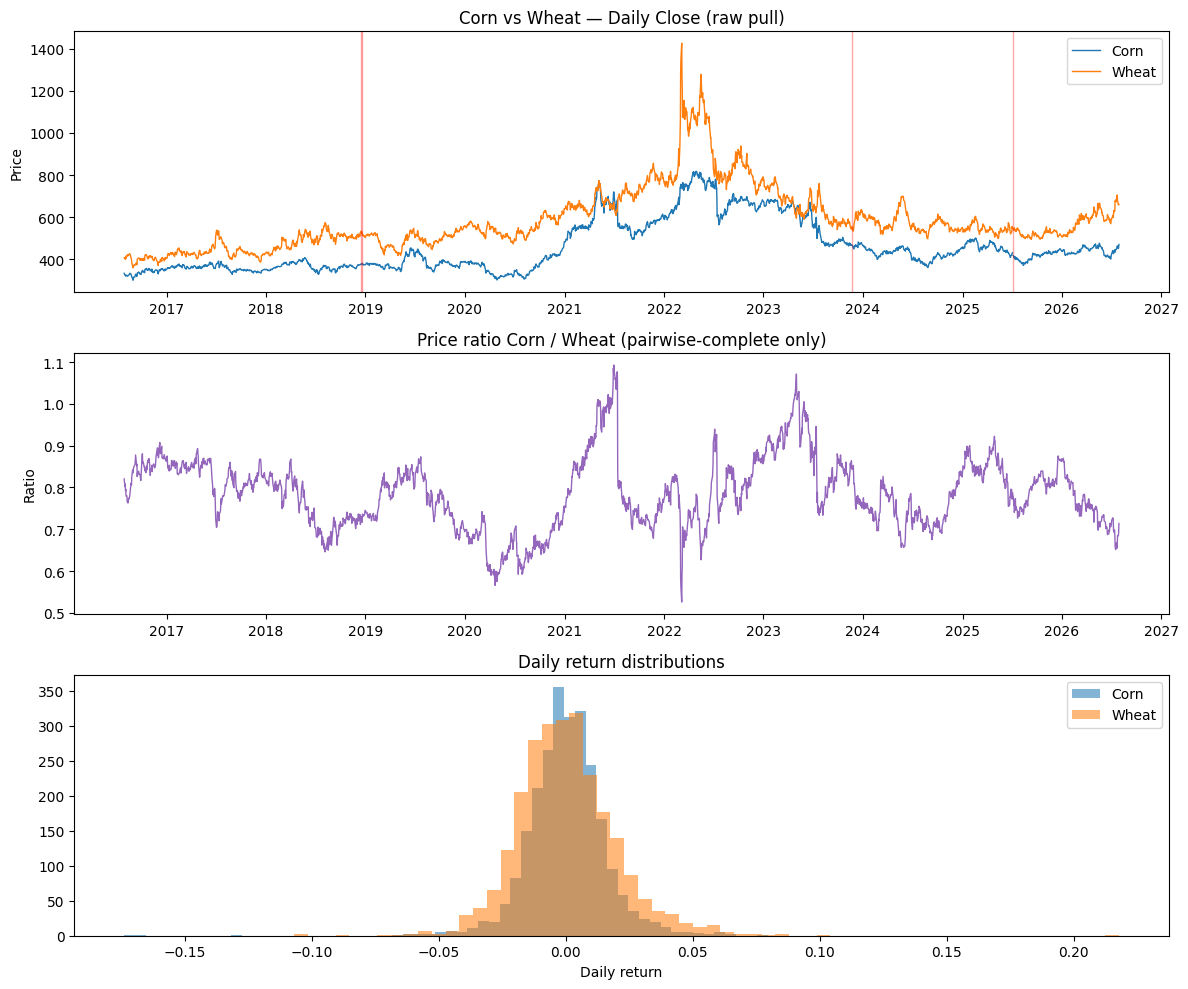

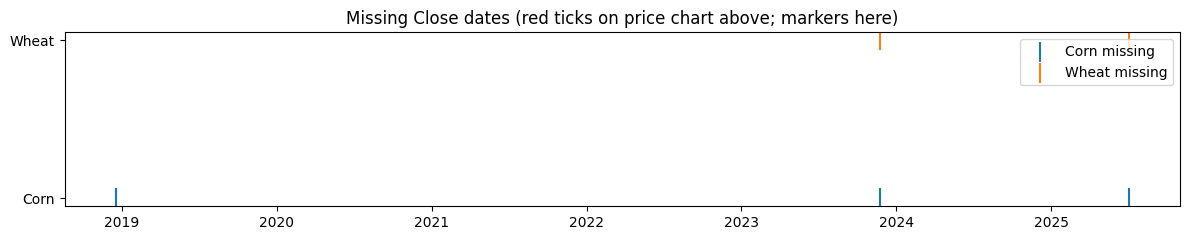

In [5]:
# Focus on the selected pair
pair_names = ["Corn", "Wheat"]
pair_raw = prices[pair_names].copy()
pair_raw.index = pd.to_datetime(pair_raw.index)

print("=" * 60)
print("1. HISTORY / COVERAGE")
print("=" * 60)
print(f"Series:            {pair_names}")
print(f"Start date:        {pair_raw.index.min().date()}")
print(f"End date:          {pair_raw.index.max().date()}")
print(f"Calendar span:     {(pair_raw.index.max() - pair_raw.index.min()).days} days")
print(f"Rows in pull:      {len(pair_raw):,}")
print(f"Trading days/year: {len(pair_raw) / ((pair_raw.index.max() - pair_raw.index.min()).days / 365.25):.1f}")
print("\nHead:")
print(pair_raw.head())
print("\nTail:")
print(pair_raw.tail())
print("\nDescriptive stats (Close):")
print(pair_raw.describe().round(3))

print("\n" + "=" * 60)
print("2. MISSING VALUES")
print("=" * 60)
missing = pair_raw.isna()
print("Missing count by series:")
print(missing.sum())
print(f"\nRows with any missing: {missing.any(axis=1).sum()}")
print(f"Rows with both present: {pair_raw.dropna().shape[0]:,}")
if missing.any(axis=None):
    print("\nDates with missing values:")
    print(pair_raw.loc[missing.any(axis=1)])
else:
    print("\nNo missing closes in either series.")

print("\n" + "=" * 60)
print("3. STRUCTURAL / CLEANLINESS CHECKS")
print("=" * 60)
# Duplicate dates
n_dupes = pair_raw.index.duplicated().sum()
print(f"Duplicate dates: {n_dupes}")

# Non-positive / invalid prices (breaks log returns & cointegration on logs)
nonpos = (pair_raw <= 0) | ~np.isfinite(pair_raw)
print(f"Non-positive or non-finite prices: {nonpos.sum().to_dict()}")

# Calendar gaps between consecutive observations
gaps_days = pair_raw.index.to_series().diff().dt.days.dropna()
print(f"\nGap between observations (days): min={gaps_days.min()}, median={gaps_days.median()}, max={gaps_days.max()}")
large_gaps = gaps_days[gaps_days > 5]  # beyond a long weekend
print(f"Gaps > 5 calendar days: {len(large_gaps)}")
if len(large_gaps):
    print(large_gaps.sort_values(ascending=False).head(10))

# Stale prints: unchanged Close day over day
unchanged = pair_raw.eq(pair_raw.shift(1))
print(f"\nUnchanged Close vs prior day: {unchanged.sum().to_dict()}")

# Extreme daily returns on pairwise-complete data
pair_ret = pair_raw.pct_change(fill_method=None)
print("\nDaily return extremes:")
for col in pair_names:
    r = pair_ret[col].dropna()
    print(
        f"  {col}: min={r.min():.2%}, max={r.max():.2%}, "
        f"|r|>10% days={(r.abs() > 0.10).sum()}, |r|>20% days={(r.abs() > 0.20).sum()}"
    )

print("\nLargest |daily returns| (possible bad prints / event days):")
big_moves = (
    pair_ret.stack()
    .abs()
    .sort_values(ascending=False)
    .head(10)
)
for (dt, name), mag in big_moves.items():
    signed = pair_ret.loc[dt, name]
    print(f"  {pd.Timestamp(dt).date()}  {name}: {signed:.2%}")

print("\n" + "=" * 60)
print("4. PAIR ALIGNMENT")
print("=" * 60)
both = pair_raw.dropna()
either_missing = pair_raw.isna().any(axis=1).sum()
print(f"Pairwise-complete observations: {len(both):,}")
print(f"Observations dropped if we require both legs: {either_missing}")
print("For pairs trading we always work on the intersection (both prices present).")

print("\n" + "=" * 60)
print("5. VENDOR / FUTURES CAVEATS TO STAY MINDFUL OF")
print("=" * 60)
print("""
- ZC=F / ZW=F are Yahoo continuous futures, not a single contract month.
  Rolls are spliced by the vendor; levels near roll dates can jump.
- Not point-in-time: today's backfill may differ from what was available historically.
- Close only: no bid/ask, volume, or open interest — costs/liquidity not measurable here.
- auto_adjust=False: we used raw Close; still subject to continuous-series construction.
- Units: grain futures are typically quoted in cents/bushel — fine for ratios/spreads
  as long as both legs use the same convention and we don't mix with equities.
""")

# --- Plots ---
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

axes[0].plot(pair_raw.index, pair_raw["Corn"], label="Corn", lw=1)
axes[0].plot(pair_raw.index, pair_raw["Wheat"], label="Wheat", lw=1)
axes[0].set_title("Corn vs Wheat — Daily Close (raw pull)")
axes[0].set_ylabel("Price")
axes[0].legend()

# Highlight missing dates on the price chart
miss_idx = pair_raw.index[pair_raw.isna().any(axis=1)]
for ax_price in (axes[0],):
    for dt in miss_idx:
        ax_price.axvline(dt, color="red", alpha=0.35, lw=1)

axes[1].plot(both.index, both["Corn"] / both["Wheat"], color="tab:purple", lw=1)
axes[1].set_title("Price ratio Corn / Wheat (pairwise-complete only)")
axes[1].set_ylabel("Ratio")

axes[2].hist(pair_ret["Corn"].dropna(), bins=60, alpha=0.55, label="Corn")
axes[2].hist(pair_ret["Wheat"].dropna(), bins=60, alpha=0.55, label="Wheat")
axes[2].set_title("Daily return distributions")
axes[2].set_xlabel("Daily return")
axes[2].legend()

plt.tight_layout()
plt.show()

# Missingness timeline (binary)
fig, ax = plt.subplots(figsize=(12, 2.5))
for i, col in enumerate(pair_names):
    m = missing[col].astype(int)
    ax.scatter(m.index[m == 1], np.full(m.sum(), i), marker="|", s=200, label=f"{col} missing")
ax.set_yticks(range(len(pair_names)))
ax.set_yticklabels(pair_names)
ax.set_title("Missing Close dates (red ticks on price chart above; markers here)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### Cleaning decision for Corn / Wheat

Practical cleaning for this pair (workshop-grade, documented):
1. Keep only pairwise-complete rows (both Corn and Wheat present).
2. Drop non-positive / non-finite prices if any appear.
3. Do **not** forward-fill across multi-day gaps for the research series — that invents prices and biases the spread.
4. Flag extreme return days for later sensitivity checks; do not auto-delete event days without evidence of a bad print.
5. Save a cleaned panel for downstream hedge-ratio / spread work.

Cleaning summary
  Raw rows:     2,514
  Clean rows:   2,510
  Dropped:      4 (0.16%)

Dropped dates and reason:
  2018-12-17: Corn=NaN
  2018-12-18: Corn=NaN
  2023-11-23: Corn=NaN, Wheat=NaN
  2025-07-04: Corn=NaN, Wheat=NaN

Wrote corn_wheat_prices_clean.csv and corn_wheat_log_prices_clean.csv

Cleaned sample window:
  2016-07-29 → 2026-07-29  (2,510 days)
Ticker      Corn     Wheat
count   2510.000  2510.000
mean     457.361   583.881
std      119.100   145.589
min      301.500   361.000
25%      367.500   500.250
50%      422.000   544.125
75%      516.062   636.938
max      818.250  1425.250


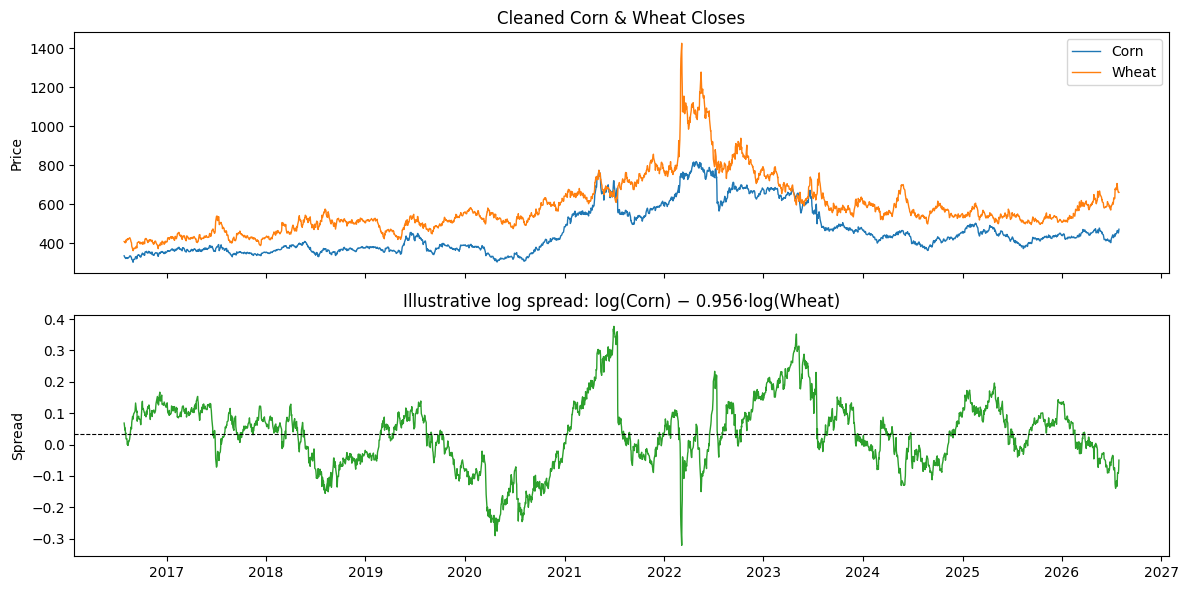

Illustrative full-sample log hedge ratio (Corn on Wheat): 0.9557
Note: a proper backtest should estimate beta only on in-sample / rolling windows (no lookahead).


In [6]:
# Build cleaned Corn/Wheat panel
pair_clean = pair_raw.copy()

# Rule 1–2: require finite, positive prices on both legs
valid = (
    pair_clean.notna().all(axis=1)
    & np.isfinite(pair_clean).all(axis=1)
    & (pair_clean > 0).all(axis=1)
)
pair_clean = pair_clean.loc[valid].sort_index()

# Diagnostics vs raw
n_raw = len(pair_raw)
n_clean = len(pair_clean)
dropped = pair_raw.index.difference(pair_clean.index)

print("Cleaning summary")
print(f"  Raw rows:     {n_raw:,}")
print(f"  Clean rows:   {n_clean:,}")
print(f"  Dropped:      {n_raw - n_clean:,} ({(n_raw - n_clean) / n_raw:.2%})")
if len(dropped):
    print("\nDropped dates and reason:")
    for dt in dropped:
        row = pair_raw.loc[dt]
        reasons = []
        for col in pair_names:
            val = row[col]
            if pd.isna(val):
                reasons.append(f"{col}=NaN")
            elif not np.isfinite(val):
                reasons.append(f"{col}=non-finite")
            elif val <= 0:
                reasons.append(f"{col}<={val}")
        print(f"  {pd.Timestamp(dt).date()}: {', '.join(reasons) if reasons else 'unknown'}")

# Log prices for later cointegration / spread steps
pair_log = np.log(pair_clean)

# Persist cleaned pair
pair_clean.to_csv("corn_wheat_prices_clean.csv")
pair_log.to_csv("corn_wheat_log_prices_clean.csv")
print("\nWrote corn_wheat_prices_clean.csv and corn_wheat_log_prices_clean.csv")

print("\nCleaned sample window:")
print(f"  {pair_clean.index.min().date()} → {pair_clean.index.max().date()}  ({len(pair_clean):,} days)")
print(pair_clean.describe().round(3))

# Quick view of cleaned levels + log spread placeholder (equal weight; hedge ratio comes next)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(pair_clean.index, pair_clean["Corn"], label="Corn", lw=1)
axes[0].plot(pair_clean.index, pair_clean["Wheat"], label="Wheat", lw=1)
axes[0].set_title("Cleaned Corn & Wheat Closes")
axes[0].legend()
axes[0].set_ylabel("Price")

# Placeholder spread using OLS hedge ratio on full clean sample (illustrative only)
beta = np.polyfit(pair_log["Wheat"], pair_log["Corn"], 1)[0]
spread = pair_log["Corn"] - beta * pair_log["Wheat"]
axes[1].plot(spread.index, spread, color="tab:green", lw=1)
axes[1].axhline(spread.mean(), color="black", lw=0.8, ls="--")
axes[1].set_title(f"Illustrative log spread: log(Corn) − {beta:.3f}·log(Wheat)")
axes[1].set_ylabel("Spread")
plt.tight_layout()
plt.show()

print(f"Illustrative full-sample log hedge ratio (Corn on Wheat): {beta:.4f}")
print("Note: a proper backtest should estimate beta only on in-sample / rolling windows (no lookahead).")
